In [ ]:
!pip3 install xgboost catboost

In [1]:
import pandas as pd
import geopandas as gpd
import shapely
from shapely import wkt
from shapely.validation import make_valid
from shapely.geometry import Polygon, MultiPolygon, Point
from shapely.strtree import STRtree
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import warnings
from tqdm import tqdm
import time
import os
import glob
from tqdm import tqdm

In [2]:
df_a = pd.read_csv('cup_it_example_src_A_cleaned.csv', index_col=0)
df_b = pd.read_csv('cup_it_example_src_B_cleaned.csv', index_col=0)

/tmp/ipykernel_37183/3017995947.py:2: DtypeWarning: Columns (0: housing) have mixed types. Specify dtype option on import or set low_memory=False.
  df_b = pd.read_csv('cup_it_example_src_B_cleaned.csv', index_col=0)


In [3]:
gdf_a = gpd.GeoDataFrame(
    df_a,
    geometry=df_a['geometry'].apply(shapely.wkt.loads)
)

gdf_b = gpd.GeoDataFrame(
    df_b,
    geometry=df_b['geometry'].apply(shapely.wkt.loads)
)


In [128]:
gdf_b['local_centroid'] = gdf_b['geometry'].apply(lambda x: x.centroid)
gdf_b['local_centroid'].head()

0     POINT (683746.463 6657410.16)
1    POINT (683990.117 6653552.609)
2     POINT (684919.91 6644539.027)
3    POINT (684234.215 6661851.248)
4    POINT (672104.457 6637113.851)
Name: local_centroid, dtype: geometry

In [4]:
gdf_a['union'] = gdf_a['union'].apply(shapely.wkt.loads)
gdf_b['union'] = gdf_b['union'].apply(shapely.wkt.loads)

gdf_a['centroid'] = gdf_a['centroid'].apply(shapely.wkt.loads)
gdf_b['centroid'] = gdf_b['centroid'].apply(shapely.wkt.loads)

In [5]:
component_to_objects_a = gdf_a.groupby(by='component')
component_to_objects_b = gdf_b.groupby(by='component')

component_a = component_to_objects_a.agg({'union': 'first'})
component_b = component_to_objects_b.agg({'union': 'first'})

a_geom = component_a['union'].values
b_geom = component_b['union'].values

united_geom = np.concat([a_geom, b_geom])
united_geom.shape, len(component_a), len(component_b)

((129875,), 88052, 41823)

In [6]:
def get_intersection_components(geometries):
    tree = STRtree(geometries)
    
    edges = []

    for i, geom in enumerate(tqdm(geometries)):
        possible_idx = tree.query(geom)

        for idx in possible_idx:
            if idx > i:
                continue
            elif geometries[idx].intersects(geom):
                edges.append((int(idx), int(i)))

    G = nx.Graph()
    G.add_edges_from(edges)

    return list(nx.connected_components(G))

intersection_components = get_intersection_components(united_geom)

100%|██████████| 129875/129875 [00:01<00:00, 88259.77it/s]


In [ ]:
# разделение индексов объединения фигур A и Б на индексы конкретно для А и конкретно для Б
def decompose(lst, b_start):
    return list(filter(lambda x: x < b_start, lst)), [i - b_start for i in lst if i >= b_start]

# получить разложение компонента связности на геометрию A и геометрию Б
def get_conn_decomposition(conn, b_start, geom_a, geom_b):
    a, b = decompose(list(conn), b_start)
    return geom_a[a], geom_b[b]

def plot_geom(geom):
    gpd.GeoDataFrame(
        geometry=geom
    ).plot()

# нарисовать общую компоненту связности по отдельности для геометрий А и Б (на разных картинках)
def plot_decomposition(conn, b_start, geom_a, geom_b):
    g_a, g_b = get_conn_decomposition(conn, b_start, geom_a, geom_b)
    plot_geom(g_a)
    plot_geom(g_b)

# Объединение фигур
def union(geometries):
    if len(geometries) == 0:
        return Point()
    
    base = geometries[0]

    for i in range(1, len(geometries)):
        base = base.union(geometries[i])

    return base

def tuple_pts_to_x_y(xy):
    return [np.array(i) for i in zip(*xy)]

def shapely_pts_to_x_y(pts):
    return tuple_pts_to_x_y([(p.x, p.y) for p in pts])

def safe_append_arr(d, key, el):
    if key not in d:
        d[key] = []
    d[key].append(el)



In [8]:
def tags_a_extract(s):
    return [el.lower() for el in eval(s) if el is not None]

tags_unique = set([t for lst in gdf_a['tags'] for t in tags_a_extract(lst)])

# print(*list(tags_unique), sep='\n')

deepseek_tags = """
спортплощадка =recr
спорт, туризм =recr
военкомат, армия =soc
мебель, интерьер =com
исправительное учреждение =soc
образование =soc
вокзал =trans
автосервис, автотехцентр =com
салон связи =com
госуслуги, служба одного окна =gov
ритуальные услуги =com
оптика =com
автосалон, авторынок =trans
кафе, ресторан =com
промышленность =prom
парковка =trans
культура и отдых =cult
стоматология =soc
строительный, хозяйственный магазин =com
фото, полиграфические услуги =com
медицина =soc
постройка, сооружение =unknown
заправочная станция =trans
общественное питание, столовая =com
аптека =soc
орган власти, администрация =gov
техника, электроника =com
продукты =com
комплекс зданий =unknown
религиозное учреждение =cult
фастфуд, быстрое питание =com
шиномонтаж =com
зоопарк, дельфинарий =cult
колледж, техникум =soc
кофейня, чайная =com
почта, услуги связи =com
государство =gov
больница, поликлиника =soc
офисы =biz
паспортная служба =gov
беседка =recr
утилизация отходов =prom
санаторий, дом отдыха =cult
автозапчасти, автоаксессуары =com
ночной клуб =com
косметика, парфюмерия =com
коммерческая организация, фирма =biz
бар, пивная =com
стилобат =com
туалет =recr
стадион, спорткомплекс =recr
подарки, сувениры =com
научное учреждение, нии =prom
трёхмерная модель =unknown
интернет-магазин, пункт выдачи =com
службы и объекты жкх =liv
медицинское учреждение =soc
юридические услуги =gov
синагога =cult
салон красоты, парикмахерская =com
морской порт, вокзал =trans
школа, гимназия =soc
фитнес, тренажёрный зал =recr
аэродром =trans
пункт техосмотра =com
посольство, консульство, визовый центр =gov
гаражный кооператив =trans
торговля =com
правоохранительные органы, спецслужбы =soc
развлекательный центр =com
антиквариат, предметы искусства =cult
суд, прокуратура =soc
автомойка =com
цветы, садоводство =com
спорт =recr
налоговая инспекция =gov
пенсионное и социальное обеспечение =gov
загс, дворец бракосочетания =gov
жилое здание =liv
спортивный объект =recr
бизнес и услуги =biz
оптовая торговля =com
книжный, канцтовары =com
транспорт =trans
бассейн =recr
торговый центр, вещевой рынок =com
парк развлечений, аттракционы =cult
церковь =cult
мусорная площадка =prom
дополнительное образование, секция =soc
штрафстоянка =trans
религия =cult
ипподром, конно-спортивные клубы =recr
ювелирные изделия =com
продуктовый рынок =com
высшее образование =soc
пожарные, спасательные службы =prom
детский сад, ясли =soc
банк =gov
кассы =com
бизнес-центр =biz
одежда, обувь, аксессуары =com
транспорт, перевозки =trans
автошкола =com
ателье, ремонт, бытовые услуги =com
выход станции скоростного транспорта =trans
мечеть =cult
гостиница, хостел =liv
велопарковка =recr
химчистка, прачечная =com
товары и услуги для животных =com
пагода =cult
культурно-развлекательное учреждение =cult
ветеринария =soc
государственное учреждение =gov
"""

d_a = {line.split(" =")[0]: line.split(" =")[1] for line in deepseek_tags.splitlines() if len(line) > 0}
d_a[np.nan] = 'unknown'

print(set(d_a.keys()).difference(set(tags_unique)))

d_b = {
    np.nan: "unknown",
    'Строение жилое (частное)': "liv",
    'Нежилое здание': 'unknown',
    'Строение дачное': 'recr',
    'Производственное здание': 'prom',
    'Производственные сооружения': 'prom',
    'Детское учреждение': 'soc',
    'Торговый центр': 'com',
    'Административное здание': 'gov',
    'Жилое здание': 'liv',
    'Учебное учреждение': 'soc',
    'Здание культурных мероприятий': 'cult',
    'Учреждение здравоохранения': 'soc',
    'Церкви': 'cult',
    'Музей': 'cult',
    'Научное здание': 'prom',
    'Капитальные сооружения башенного типа': 'unknown'
}

gdf_a['common_tags'] = gdf_a['tags'].apply(tags_a_extract).apply(lambda tags: list(map(lambda t: d_a[t], tags)))
gdf_b['common_tag'] = gdf_b['purpose_of_building'].apply(lambda x: d_b[x])

{nan}


In [286]:
import numpy as np
from typing import List, Tuple

def assign_points_to_cells(points, N: int):
    # Extract x and y coordinates
    x_coords = [p[0] for p in points]
    y_coords = [p[1] for p in points]

    # Calculate bounds
    x_min, x_max = min(x_coords), max(x_coords)
    y_min, y_max = min(y_coords), max(y_coords)

    # Calculate cell dimensions
    cell_width = (x_max - x_min) / N
    cell_height = (y_max - y_min) / N

    # Create 2D numpy array of empty lists
    grid = [[[] for j in range(N)] for i in range(N)]

    # Assign each point to a cell
    for idx, (x, y) in enumerate(points):
        # Calculate cell indices
        # Handle edge case: when x == x_max, it should go to last cell
        col = min(int((x - x_min) / cell_width), N - 1)
        row = min(int((y - y_min) / cell_height), N - 1)

        # Add point index to corresponding cell
        grid[row][col].append(idx)

    grid = grid[::-1]

    return grid

N = 30

assigned_sector_a = np.zeros((len(gdf_a),), dtype=int)
assigned_sector_b = np.zeros((len(gdf_b),), dtype=int)
points_to_assign = [(c.x, c.y) for c in gdf_a['centroid']] + [(c.x, c.y) for c in gdf_b['centroid']]
b_start = len(gdf_a)

grid =  assign_points_to_cells(points_to_assign, N)

for i in range(N):
    for j in range(N):
        indices = grid[i][j]
        sector_id = i * N + j
        a_idx, b_idx = decompose(indices, b_start)
        assigned_sector_a[a_idx] = sector_id
        assigned_sector_b[b_idx] = sector_id

gdf_a['sector'] = assigned_sector_a
gdf_b['sector'] = assigned_sector_b

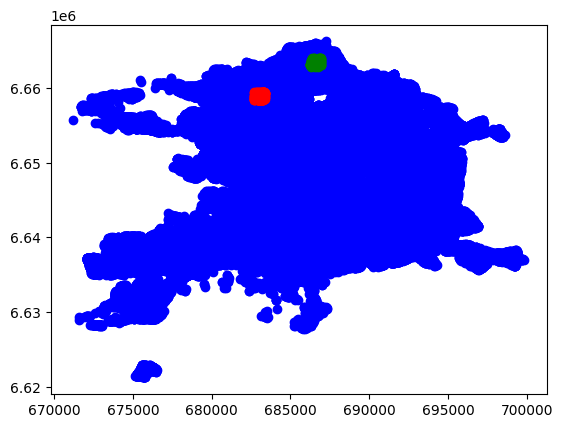

In [273]:
plt.scatter(*shapely_pts_to_x_y(gdf_a['centroid']), color='blue')
plt.scatter(*shapely_pts_to_x_y(gdf_a[gdf_a['sector'] == 256]['centroid']), color='red')
plt.scatter(*shapely_pts_to_x_y(gdf_a[gdf_a['sector'] == 101]['centroid']), color='green')

In [274]:
common_tags = list(set(d_a.values()))
common_tags.remove('unknown')
print(common_tags)

['recr', 'biz', 'trans', 'liv', 'com', 'soc', 'gov', 'prom', 'cult']


In [12]:
def is_ct(ct):
    return f'is_{ct}'

def is_ct_arr(ct_arr):
    return [is_ct(cti) for cti in ct_arr]

def extend_obj_df_with_tag(df, col_of_arr):
    df = df.copy()
    
    for ct in common_tags:
        df[is_ct(ct)] = col_of_arr.apply(lambda x: ct in x)

    return df

if 'common_tags' in gdf_a and 'common_tag' in gdf_b:
    gdf_a = extend_obj_df_with_tag(gdf_a, gdf_a['common_tags'])
    gdf_b = extend_obj_df_with_tag(gdf_b, gdf_b['common_tag'].apply(lambda x: [x]))

    gdf_a.drop(['tags', 'common_tags'], axis=1, inplace=True)
    gdf_b.drop(['purpose_of_building', 'common_tag'], axis=1, inplace=True)

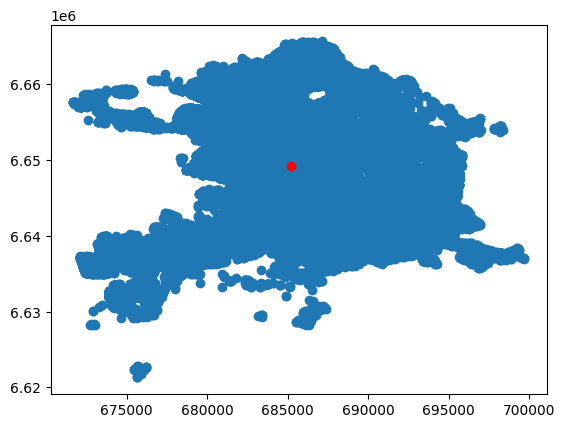

In [13]:
center_coords_s = 'Point(30.315473 59.938991)' # дворцовая площадь

cc_gpd = gpd.GeoSeries([shapely.wkt.loads(center_coords_s)], crs='EPSG:4326')
cc_gpd = cc_gpd.to_crs('EPSG:32635')

city_center = cc_gpd.geometry[0]

plt.scatter(gdf_b['centroid'].apply(lambda x: x.x), gdf_b['centroid'].apply(lambda x: x.y))
plt.scatter([city_center.x], [city_center.y], color='red')

In [235]:
#### АГГРЕГАЦИЯ

from sklearn.model_selection import train_test_split

train_index, test_index = train_test_split(gdf_b.index, test_size=0.2)
gdf_b_train, gdf_b_test = gdf_b.loc[train_index], gdf_b.loc[test_index] 

In [236]:
from tqdm import tqdm

gdf_parts = []

for ic in tqdm(intersection_components):
    a_component_idx, b_component_idx = decompose(list(ic), len(component_a))
    gdf_a_part = gdf_a[gdf_a['component'].isin(a_component_idx)]
    gdf_b_part = gdf_b[gdf_b['component'].isin(b_component_idx)]
    gdf_parts.append((gdf_a_part, gdf_b_part))

100%|██████████| 89175/89175 [02:52<00:00, 516.39it/s]


In [237]:
gdf_b_part.columns

Index(['subject', 'district', 'type', 'locality', 'type_street', 'name_street',
       'number', 'letter', 'fraction', 'housing', 'building', 'stairs',
       'avg_floor_height', 'height', 'wkt', 'id', 'stairs_numeric',
       'avg_floor_height_numeric', 'height_calculated', 'height_numeric',
       'geometry', 'area_m2', 'component', 'is_isolated', 'centroid', 'union',
       'sector', 'is_recr', 'is_biz', 'is_trans', 'is_liv', 'is_com', 'is_soc',
       'is_gov', 'is_prom', 'is_cult', 'local_centroid'],
      dtype='str')

In [238]:
building_geometrical = {}

for i, (gdf_a_part, gdf_b_part) in enumerate(tqdm(gdf_parts)):

    geom = union([union(gdf_a_part['geometry'].values), union(gdf_b_part['geometry'].values)])
    cvx = geom.convex_hull

    safe_append_arr(building_geometrical, 'geometry', geom)
    safe_append_arr(building_geometrical, 'centroid', geom.centroid)
    safe_append_arr(building_geometrical, 'area', geom.area)
    safe_append_arr(building_geometrical, 'convex_area', cvx.area)
    safe_append_arr(building_geometrical, 'perimeter', geom.length)
    safe_append_arr(building_geometrical, 'convex_perimeter', cvx.length)
    

  0%|          | 0/89175 [00:00<?, ?it/s]

100%|██████████| 89175/89175 [00:10<00:00, 8797.35it/s] 


In [312]:
assigned_building_a = np.zeros((len(gdf_a),), dtype=int)
assigned_building_b = np.zeros((len(gdf_b),), dtype=int)
buildings = []

def collect_unique_tags(binary_df):
    tags = set()

    for i, row in binary_df.iterrows():
        for ct in common_tags:
            if row[is_ct(ct)]:
                tags.add(ct)
    
    return tags

for i, (gdf_a_part, gdf_b_part) in enumerate(tqdm(gdf_parts)):
    building = {
        key: v[i]
        for key, v in building_geometrical.items()
    }

    unique_tags = collect_unique_tags(gdf_a_part) | collect_unique_tags(gdf_b_part)

    building['compactness'] =  np.sqrt(building['area']) / building['perimeter'] * 100
    building['convex_compactness'] =  np.sqrt(building['convex_area']) / building['convex_perimeter'] * 100
    building['num_objects'] = len(gdf_a_part) + len(gdf_b_part)
    building['object_density'] = building['num_objects'] / building['convex_area']
    building['is_liv_plus_com'] = set(['com', 'liv']).issubset(unique_tags)
    building['n_unique_tags'] = len(unique_tags)
    building['inner'] = (building['convex_area'] - building['area']) / building['convex_area']
    
    building['gkh_floor_count_min'] = gdf_a_part['gkh_floor_count_min'].min()
    building['gkh_floor_count_max'] = gdf_a_part['gkh_floor_count_max'].max()
    
    # test
    
    building['distance_to_city_center'] = city_center.distance(building['centroid'])

    assigned_building_a[gdf_a_part.index.values] = i
    assigned_building_b[gdf_b_part.index.values] = i

    buildings.append(building)


buildings = pd.DataFrame({
    key: [b[key] for b in buildings]
    for key in buildings[0].keys()
})

100%|██████████| 89175/89175 [00:27<00:00, 3216.46it/s]


In [328]:
import numpy as np
from scipy.spatial import KDTree
from shapely.geometry import Point
from typing import List, Tuple

def find_nearest_points_kdtree(
    query_points: List[Tuple[float, float]],
    target_points: List[Tuple[float, float]],
    n: int
) -> List[List[Tuple[Point, float]]]:
    """
    Find N nearest neighbors using KD-tree for efficiency.
    Best for large datasets (thousands of points).
    """
    # Build KD-tree from target points
    target_arr = np.array(target_points)
    kdtree = KDTree(target_arr)
    
    # Query all points at once
    distances, indices = kdtree.query(query_points, k=min(n, len(target_points)))
    
    # Handle case when n=1 (distances and indices are 1D)
    if n == 1:
        distances = [distances]
        indices = [indices]
    
    # Prepare results
    results = []
    for i, (query_distances, query_indices) in enumerate(zip(distances, indices)):
        query_results = []

        for dist, idx in zip(query_distances, query_indices):
            target_point = Point(target_arr[idx])
            query_results.append((int(idx), float(dist)))
        
        results.append(query_results)
    
    return results


from scipy.spatial import KDTree

def count_points_in_radius_kdtree(
    query_points: List[Tuple[float, float]],
    target_points: List[Tuple[float, float]],
    radius: float
) -> List[int]:
    """
    KD-tree based version - faster for large datasets.
    
    Uses scipy.spatial.KDTree for efficient radius queries.
    """
    
    
    # Build KD-tree from target points
    target_arr = np.array(target_points)
    kdtree = KDTree(target_arr)
    
    # Query all points at once
    query_arr = np.array(query_points)
    counts = kdtree.query_ball_point(query_arr, radius, return_length=True)
    
    return counts.tolist()

In [ ]:
M = 10

pts = list(buildings['centroid'].apply(lambda x: (x.x, x.y)))

nearest_points = find_nearest_points_kdtree(pts, pts, M + 1)

In [ ]:
def get_max_floor_count(indices):
    return buildings.loc[indices]['gkh_floor_count_max'].max()

def extract_closest_indices(nearest_result):
    return [idx for idx, _ in nearest_result[1:]]

buildings['distance_to_nearest_buildings'] = np.array([sum(dist for _, dist in nearest_arr[1:]) / M for nearest_arr in tqdm(nearest_points)]) / np.sqrt(buildings['convex_area'])
buildings['nearest_buildings_gkh_floor_count_max'] = [get_max_floor_count(extract_closest_indices(nearest_arr)) for nearest_arr in tqdm(nearest_points)]


100%|██████████| 89175/89175 [00:10<00:00, 8423.00it/s]


In [329]:
R1 = 50
R2 = 100
R3 = 250

buildings['density_R1'] = count_points_in_radius_kdtree(pts, pts, R1)
print('R1 DONE')
buildings['density_R2'] = count_points_in_radius_kdtree(pts, pts, R2)
print('R2 DONE')
buildings['density_R3'] = count_points_in_radius_kdtree(pts, pts, R3)
print('R3 DONE')

R1 DONE
R2 DONE
R3 DONE


<Axes: >

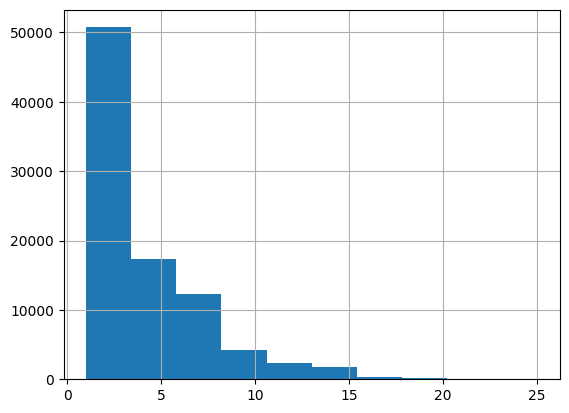

In [333]:
buildings['density_R1'].hist()

<Axes: >

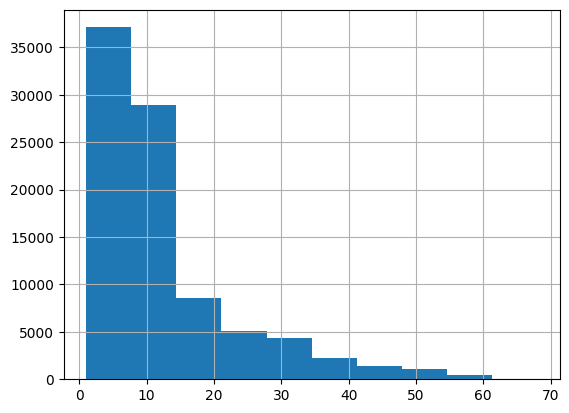

In [334]:
buildings['density_R2'].hist()

<Axes: >

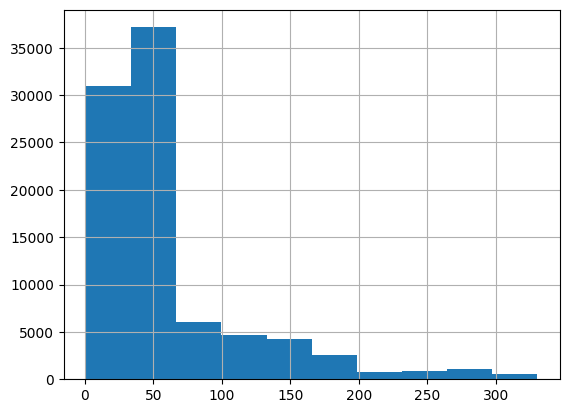

In [335]:
buildings['density_R3'].hist()

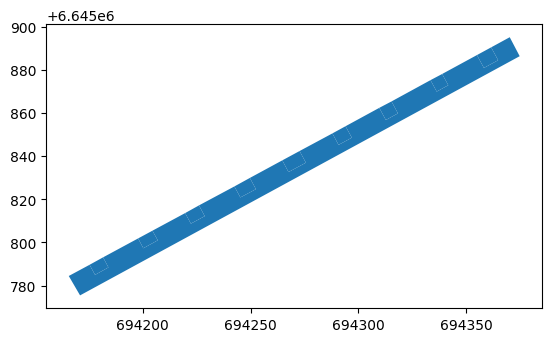

In [244]:
def plot_building(idx):
    gdf_a_part, gdf_b_part = gdf_parts[idx]

    gpd.GeoDataFrame(geometry=np.concat([gdf_a_part.geometry, gdf_b_part.geometry])).plot()

plot_building(88868)

In [287]:
sector_to_objects_a = gdf_a.groupby(by='sector')
sector_to_objects_b = gdf_b_train.groupby(by='sector') # без утечки

is_ct_columns = [is_ct(ct) for ct in common_tags]

sectors = [None] * (N ** 2)

for i in range(N**2):
    gdf_a_part = gdf_a.loc[[]] if i not in sector_to_objects_a.groups else sector_to_objects_a.get_group(i)
    gdf_b_part = gdf_b_train.loc[[]] if i not in sector_to_objects_b.groups else sector_to_objects_b.get_group(i)

    sector = {}

    building['gkh_floor_count_mid'] = (gdf_a_part['gkh_floor_count_min'] + gdf_a_part['gkh_floor_count_max']).mean() / 2
    sector['density'] = len(set(gdf_a_part['component']) | set(gdf_b_part['component']))

    tca = gdf_a_part.filter(is_ct_columns).sum()
    tcb = gdf_b_part.filter(is_ct_columns).sum()
    tag_frequency = (tca + tcb) / (tca.sum() + tcb.sum() + 1e-7)

    for col in tag_frequency.index:
        sector[col + '_freq'] = tag_frequency[col]

    #for ct in common_tags:
    #    sector[f'{ct}_median_floor_height'] = gdf_b_part[gdf_b_part[is_ct(ct)]]['avg_floor_height'].median()
    #    sector[f'{ct}_median_height'] = gdf_b_part[gdf_b_part[is_ct(ct)]]['height'].median()
    #    sector[f'{ct}_median_stairs'] = gdf_b_part[gdf_b_part[is_ct(ct)]]['stairs'].median()

    sectors[i] = sector

sectors = pd.DataFrame({
    key: [b[key] for b in sectors]
    for key in sectors[0].keys()
})

In [288]:
sectors.loc[100:200].head()

,density,is_recr_freq,is_biz_freq,is_trans_freq,is_liv_freq,is_com_freq,is_soc_freq,is_gov_freq,is_prom_freq,is_cult_freq
100,96,0.000000,0.014085,0.000000,0.464789,0.000000,0.028169,0.014085,0.478873,0.000000
101,214,0.013072,0.013072,0.000000,0.509804,0.000000,0.052288,0.013072,0.392157,0.006536
102,530,0.000000,0.008721,0.002907,0.979651,0.002907,0.000000,0.002907,0.002907,0.000000
103,535,0.010753,0.045699,0.008065,0.798387,0.043011,0.018817,0.010753,0.043011,0.021505
104,270,0.023404,0.027660,0.000000,0.780851,0.082979,0.061702,0.019149,0.004255,0.000000


In [289]:
# common form -> area

def construct_building_df(assigned_buildings_idx):
    return buildings.loc[assigned_buildings_idx].reset_index(drop=True)

def construct_sector_df(assigned_sector_idx):
    return sectors.loc[assigned_sector_idx].reset_index(drop=True)


def to_common_form_a(df_a):
    area = df_a['geometry'].apply(lambda x: x.area)

    return pd.DataFrame({
        'area': area
    })

def assign_series_with_prefix(dict_, df_orig, prefix, column):
    dict_[prefix + '_' + column] = df_orig[column]

def to_common_form_b(df_b):
    d = {}

    d['area'] = df_b['geometry'].apply(lambda x: x.area)
    d['height'] = df_b['height']
    d['sector'] = df_b['sector']

    assigned_building_df = construct_building_df(assigned_building_b)
    assigned_sector_df = construct_sector_df(df_b['sector'])
    ignore_building_columns = ['geometry', 'centroid']

    for col in assigned_building_df.columns:
        if col in ignore_building_columns:
            continue
        assign_series_with_prefix(d, assigned_building_df, 'building', col)

    for col in assigned_sector_df.columns:
        assign_series_with_prefix(d, assigned_sector_df, 'sector', col)

    for ct in common_tags:
        d[is_ct(ct)] = df_b[is_ct(ct)]

    d['area_frac'] = d['area'].div(d['building_area'])
    d['distance_from_building_centroid'] = pd.Series(
        data=[row['local_centroid'].distance(row['centroid']) for i, row in df_b.iterrows()]) / (assigned_building_df['convex_area'] ** 0.5)

    return pd.DataFrame(d)

In [336]:
b_common_form = to_common_form_b(gdf_b)
b_common_form.head()

,area,height,sector,building_area,building_convex_area,building_perimeter,building_convex_perimeter,building_compactness,building_convex_compactness,building_num_objects,...,is_biz,is_trans,is_liv,is_com,is_soc,is_gov,is_prom,is_cult,area_frac,distance_from_building_centroid
0,2851.000035,28.0,163,14875.743484,20570.431759,1179.877503,624.801150,10.337188,22.955137,16,...,False,False,False,False,False,False,False,False,0.191654,0.000000
1,432.214482,23.0,253,1443.840775,1663.976161,244.842087,154.480046,15.519352,26.405911,11,...,False,False,False,False,False,False,False,False,0.299351,0.324156
2,1687.079132,49.0,434,2137.965858,3565.002522,295.733826,249.147494,15.635054,23.964777,2,...,False,False,False,False,False,False,False,False,0.789105,0.000000
3,137.321717,15.0,73,625.704755,853.195754,169.118268,113.824643,14.790887,25.661855,6,...,False,False,False,False,False,False,False,False,0.219467,0.122527
4,37.263166,6.6,570,37.263166,37.263166,25.438360,25.438360,23.996658,23.996658,1,...,False,False,True,False,False,False,False,False,1.000000,0.000000


In [337]:
b_common_form.columns

Index(['area', 'height', 'sector', 'building_area', 'building_convex_area',
       'building_perimeter', 'building_convex_perimeter',
       'building_compactness', 'building_convex_compactness',
       'building_num_objects', 'building_object_density',
       'building_is_liv_plus_com', 'building_n_unique_tags', 'building_inner',
       'building_gkh_floor_count_min', 'building_gkh_floor_count_max',
       'building_distance_to_city_center',
       'building_distance_to_nearest_buildings',
       'building_nearest_buildings_gkh_floor_count_max', 'building_density_R1',
       'building_density_R2', 'building_density_R3', 'sector_density',
       'sector_is_recr_freq', 'sector_is_biz_freq', 'sector_is_trans_freq',
       'sector_is_liv_freq', 'sector_is_com_freq', 'sector_is_soc_freq',
       'sector_is_gov_freq', 'sector_is_prom_freq', 'sector_is_cult_freq',
       'is_recr', 'is_biz', 'is_trans', 'is_liv', 'is_com', 'is_soc', 'is_gov',
       'is_prom', 'is_cult', 'area_frac', 'distan

In [338]:
x_train = b_common_form.loc[train_index].drop(['height'], axis=1)
y_train = b_common_form.loc[train_index]['height']

x_test = b_common_form.loc[test_index].drop(['height'], axis=1)
y_test = b_common_form.loc[test_index]['height']

In [339]:
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

"""
-0.29

0.68

0.75

0.84
0.85
0.86
"""


#reg = RandomForestRegressor().fit(x_train, y_train) 0.86
reg = XGBRegressor(max_depth=11).fit(x_train, y_train)
#reg = CatBoostRegressor().fit(x_train, y_train)

train_index, test_index = train_test_split(gdf_b.index, test_size=0.2)
gdf_b_train, gdf_b_test = gdf_b.loc[train_index], gdf_b.loc[test_index] 
reg.score(x_test, y_test)

0.8747561868392363

In [340]:
def get_feature_importance_dataframe(model, feature_names, importance_type='weight'):
    """Return feature importance as sorted DataFrame."""
    
    if importance_type in ['weight', 'gain', 'cover']:
        importance = model.get_booster().get_score(importance_type=importance_type)
        
        # Fill missing features with 0
        df = pd.DataFrame({
            'feature': feature_names,
            'importance': [importance.get(f, 0) for f in feature_names]
        })
    else:
        # Default feature_importances_
        df = pd.DataFrame({
            'feature': feature_names,
            'importance': model.feature_importances_
        })
    
    return df.sort_values('importance', ascending=False)


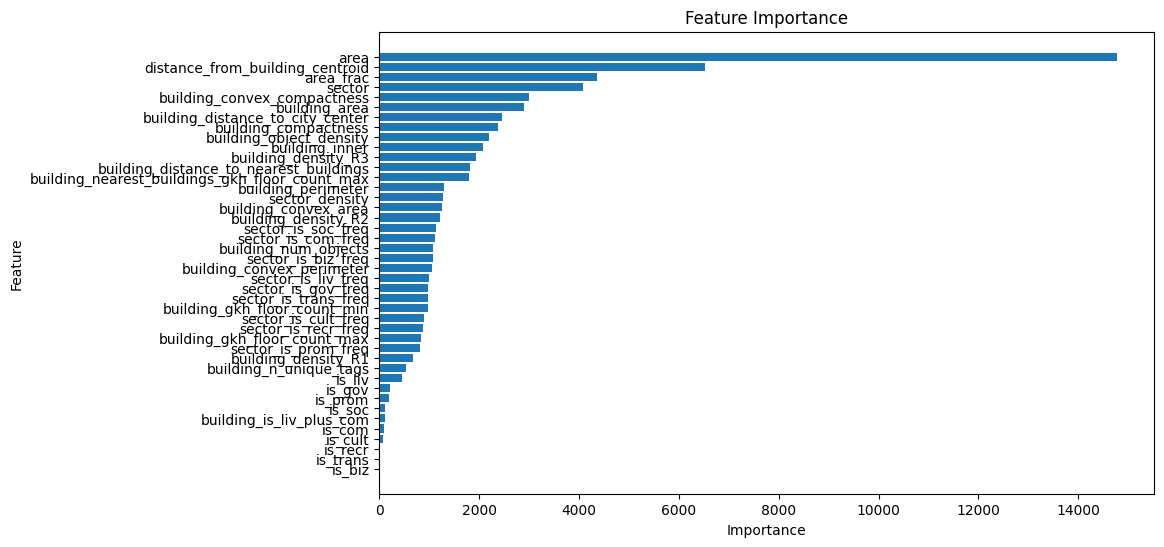

In [347]:
imp = get_feature_importance_dataframe(reg, x_test.columns)

plt.figure(figsize=(10, 6))
plt.barh(imp['feature'][::-1], imp['importance'][::-1])
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [252]:
x_test_pred = x_test.copy()
x_test_pred['pred'] = reg.predict(x_test)
x_test_pred[['pred']].to_csv('x_test_pred.csv')

In [ ]:
gdf_b

<Axes: >

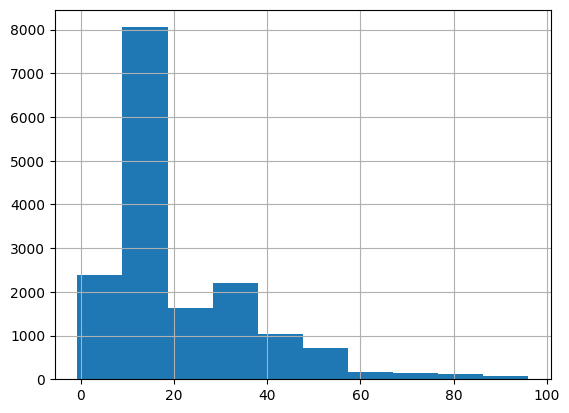

In [254]:
x_test_pred['pred'].hist()

<Axes: >

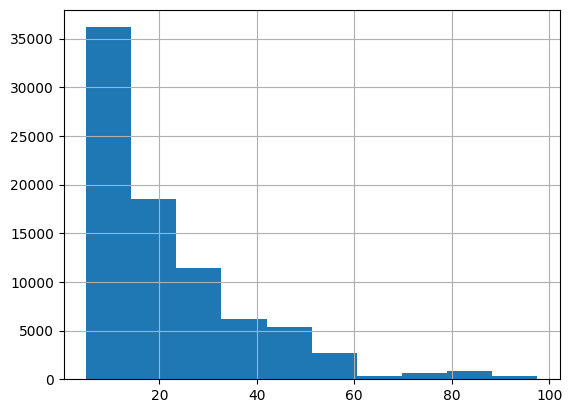

In [ ]:
gdf_b['height'].hist()

0.4237656834100568

In [ ]:
triple = list(filter(lambda x: len(x) > 3, intersection_components))

In [ ]:
building = collect_building_info(triple[2])

push_back_and_assign(triple[2], building)

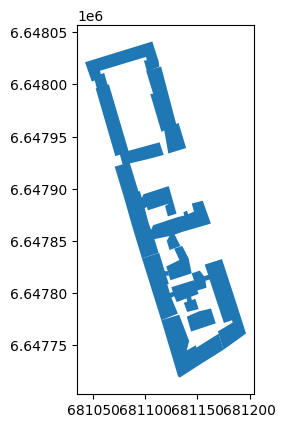

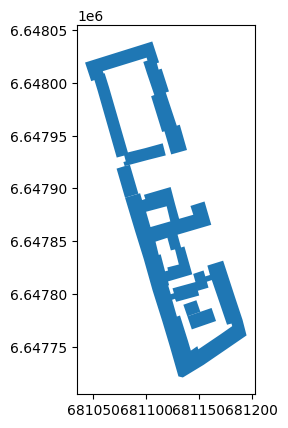

In [ ]:
plot_decomposition(triple[2], b_start, a_geom, b_geom)

{nan}
